# **1 数据预处理**

In [2]:
import numpy as np
import pandas as pd 
# 读取数据
data = pd.read_csv(r"/kaggle/input/pv-data/train_1.csv")
data.head(5)

,时间,辐照度,风速,风向,温度,湿度,压强,实际辐照度,实际功率
0,2017-01-01 00:15:00,-1.0,-0.855915,0.291529,-0.459561,-0.207037,0.043513,0.0,0.039000
1,2017-01-01 00:30:00,-1.0,-0.851950,0.395271,-0.462905,-0.200263,0.042722,0.0,0.039000
2,2017-01-01 00:45:00,-1.0,-0.847984,0.497236,-0.465831,-0.192790,0.041930,0.0,0.042333
3,2017-01-01 01:00:00,-1.0,-0.844019,0.592254,-0.469592,-0.184763,0.041139,0.0,0.042667
4,2017-01-01 01:15:00,-1.0,-0.838731,0.675103,-0.473354,-0.176346,0.040348,0.0,0.042667


In [3]:
# 重命名列
data.rename(columns={
    '时间': 'Time',
    '辐照度': 'Global_Radiation',
    '风速': 'Wind_speed',
    '风向': 'Wind_Direction',
    '压强': 'Pressure',
    '湿度': 'Humidity',
    '温度': 'Temperature',
    '实际功率': 'Actual_Power'
}, inplace=True)
data['Time'] = pd.to_datetime(data['Time'])
data.drop('实际辐照度',axis=1,inplace=True)

# 设置时间过滤条件
start_time = '08:00:00'
end_time = '18:00:00'
# 过滤数据
data = data[(data['Time'].dt.time >= pd.to_datetime(start_time).time()) &
                     (data['Time'].dt.time <= pd.to_datetime(end_time).time())]
data['Actual_Power'] = data['Actual_Power'].apply(lambda x: 0 if x < 0 else x)
data.head(5)

,Time,Global_Radiation,Wind_speed,Wind_Direction,Temperature,Humidity,Pressure,Actual_Power
31,2017-01-01 08:00:00,-1.000000,-0.185724,0.623205,-0.572832,0.036912,0.117089,0.039333
32,2017-01-01 08:15:00,-1.000000,-0.188367,0.623593,-0.569070,0.032559,0.126582,0.000000
33,2017-01-01 08:30:00,-1.000000,-0.194977,0.623927,-0.559875,0.020365,0.138449,0.000000
34,2017-01-01 08:45:00,-0.965188,-0.204230,0.624205,-0.546917,0.001560,0.151108,0.174000
35,2017-01-01 09:00:00,-0.899902,-0.216127,0.624371,-0.530199,-0.022623,0.164557,0.582667


## 1.1 相关性分析

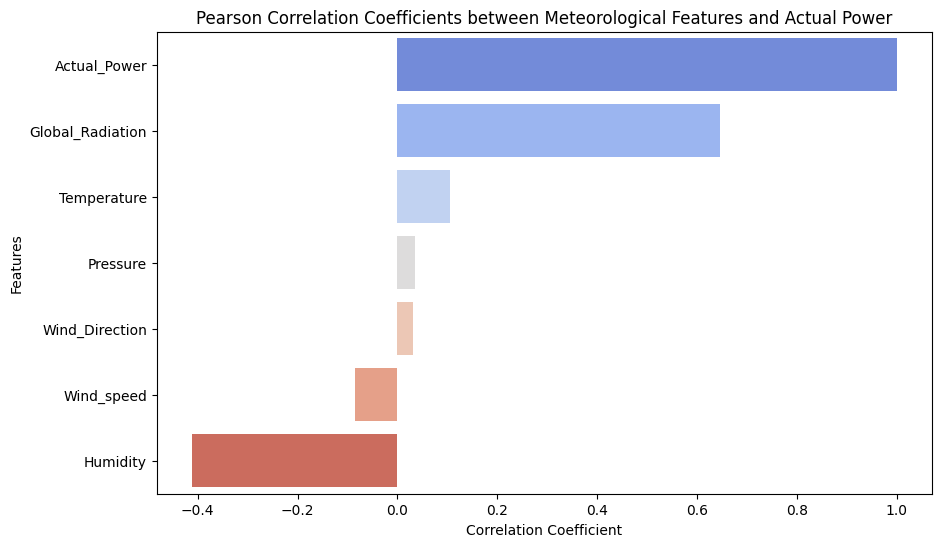

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 计算各气象特征与实际功率的皮尔逊相关系数
# 排除时间列
correlation = data.drop('Time', axis=1).corr()['Actual_Power'].sort_values(ascending=False)

# 绘制条形图
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation.values, y=correlation.index, palette='coolwarm')

# 添加标题和标签
plt.title('Pearson Correlation Coefficients between Meteorological Features and Actual Power')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')

# 显示图形
plt.show()

可以发现结果和论文中比较接近，说明论文应该用的也是第一个电站的数据。

## 1.2 异常值处理

Column: Global_Radiation, Number of outliers: 0
Column: Wind_speed, Number of outliers: 1292
Column: Wind_Direction, Number of outliers: 0
Column: Temperature, Number of outliers: 0
Column: Humidity, Number of outliers: 0
Column: Pressure, Number of outliers: 404


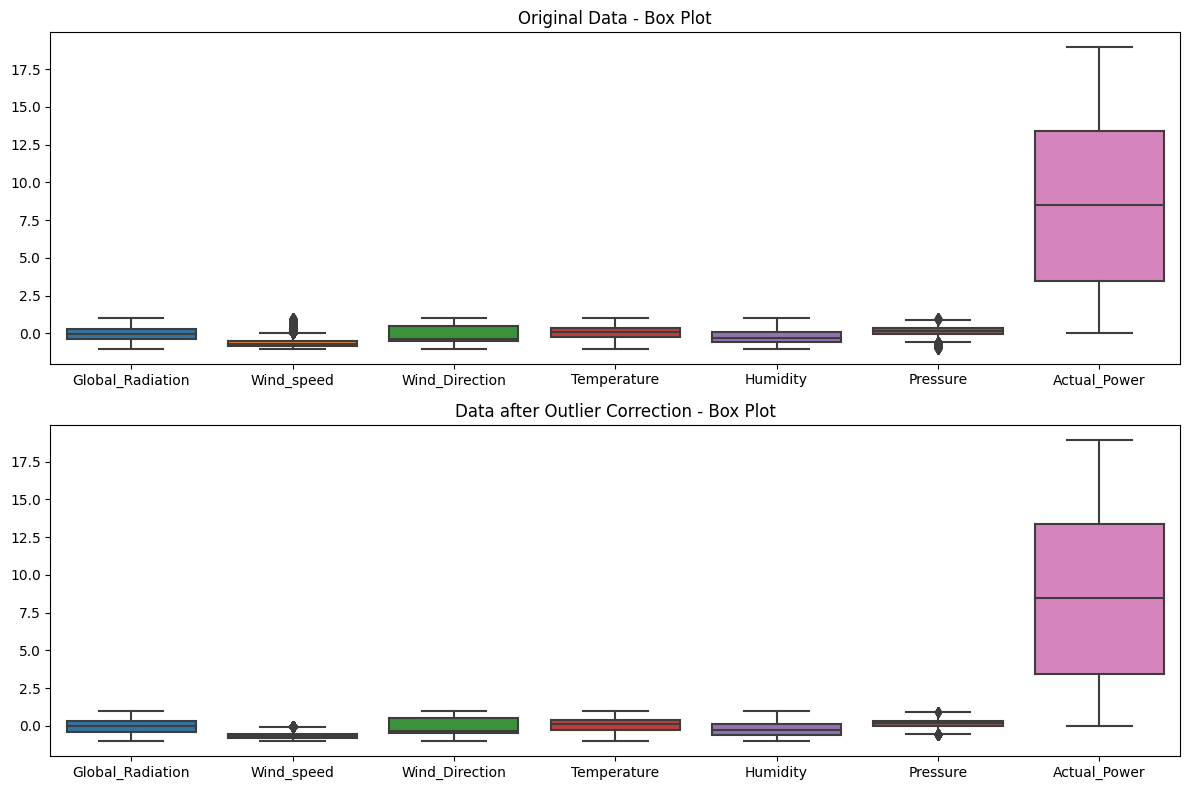

In [5]:
# 定义一个函数来检测并修正异常值
def detect_and_replace_outliers(data, column):
    # 计算四分位数
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # 定义异常值的范围
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 检测异常值
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    # 用均值填充异常值
    mean_value = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)][column].mean()
    data[column] = data[column].apply(lambda x: mean_value if x < lower_bound or x > upper_bound else x)
    
    return data, outliers

# 绘制箱线图检测异常值
plt.figure(figsize=(12, 8))

# 绘制原始数据的箱线图
plt.subplot(2, 1, 1)
sns.boxplot(data=data.drop('Time', axis=1))
plt.title('Original Data - Box Plot')

# 对每个数值列检测并修正异常值
for column in data.select_dtypes(include=['float64', 'int64']).columns:
    if column != 'Actual_Power':  # 假设 Actual_Power 是目标变量，不对其进行修正
        data, outliers = detect_and_replace_outliers(data, column)
        print(f"Column: {column}, Number of outliers: {len(outliers)}")

# 绘制修正后的箱线图
plt.subplot(2, 1, 2)
sns.boxplot(data=data.drop('Time', axis=1))
plt.title('Data after Outlier Correction - Box Plot')

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

## 1.3 ＧＭＭ相似日样本聚类

原文中说到：根据光伏发电功率在一天之内的波动频率特点可以得到３种天气的样本数据，因此聚类的输入应该是功率的特征，由于文章没有细说，所以这里简单选择三个特征'sum', 'max', 'std'。

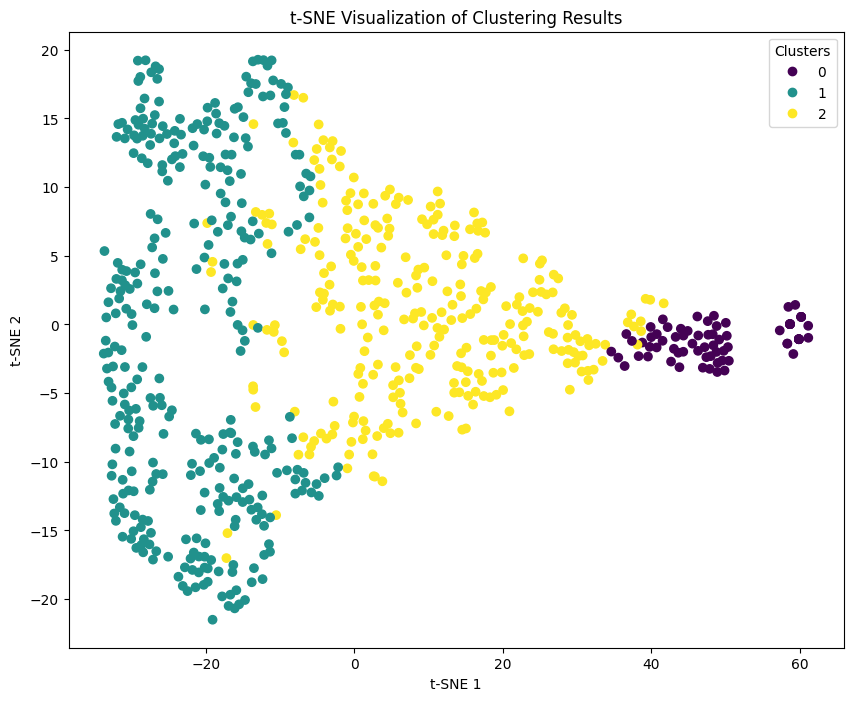

In [6]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 按天分组，提取每天的特征
daily_data = data.groupby(data['Time'].dt.date).agg({
    'Actual_Power': ['sum', 'max', 'std']
}).reset_index()
daily_data.columns = ['Date', 'Daily_Total_Power', 'Daily_Peak_Power', 'Daily_Power_Std']
# 标准化数据
features = ['Daily_Total_Power', 'Daily_Peak_Power', 'Daily_Power_Std']
scaler = StandardScaler()
daily_data_scaled = scaler.fit_transform(daily_data[features])

# 使用GMM进行聚类，初步聚类为3种
gmm = GaussianMixture(n_components=3, random_state=42)
daily_data['Cluster'] = gmm.fit_predict(daily_data_scaled)

# 使用t-SNE进行降维
tsne = TSNE(n_components=2, random_state=42)
daily_data_tsne = tsne.fit_transform(daily_data_scaled)

# 将t-SNE的结果添加到数据框中
daily_data['TSNE_1'] = daily_data_tsne[:, 0]
daily_data['TSNE_2'] = daily_data_tsne[:, 1]
# 绘制t-SNE降维后的散点图
plt.figure(figsize=(10, 8))
scatter = plt.scatter(daily_data['TSNE_1'], daily_data['TSNE_2'], c=daily_data['Cluster'], cmap='viridis')
plt.title('t-SNE Visualization of Clustering Results')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

样本数量应该是晴天>多云>雨天，因此把三类数据分类。

In [7]:
# 确保原始数据中有日期信息
data['Date'] = data['Time'].dt.date

# 将聚类结果合并到原始数据中
data_with_cluster = data.merge(daily_data[['Date', 'Cluster']], on='Date', how='left')

# 按照聚类结果将数据分割并保存到不同的文件中
for cluster in data_with_cluster['Cluster'].unique():
    cluster_data = data_with_cluster[data_with_cluster['Cluster'] == cluster]
    cluster_data.to_csv(f'/kaggle/working/cluster_{cluster}_data.csv', index=False)
    print(f'Cluster {cluster} data saved to cluster_{cluster}_data.csv')

Cluster 2 data saved to cluster_2_data.csv
Cluster 0 data saved to cluster_0_data.csv
Cluster 1 data saved to cluster_1_data.csv


# **２预测模型构建**

为了减少同一个变量的重复调用，现在重新读取三个类的csv文件来进行后续预测

In [8]:
data_sunny = pd.read_csv(r"/kaggle/working/cluster_1_data.csv")
data_cloudy = pd.read_csv(r"/kaggle/working/cluster_2_data.csv")
data_rainy = pd.read_csv(r"/kaggle/working/cluster_0_data.csv")

data_sunny.drop(columns=['Date','Cluster'],inplace=True)
data_cloudy.drop(columns=['Date','Cluster'],inplace=True)
data_rainy.drop(columns=['Date','Cluster'],inplace=True)

data_sunny.head(5)

,Time,Global_Radiation,Wind_speed,Wind_Direction,Temperature,Humidity,Pressure,Actual_Power
0,2017-02-23 08:00:00,-1.000000,-0.648381,-0.430445,-0.629258,0.280429,0.051424,0.045667
1,2017-02-23 08:15:00,-0.967298,-0.647059,-0.433168,-0.627586,0.272218,0.057753,0.024667
2,2017-02-23 08:30:00,-0.900159,-0.643093,-0.440613,-0.622571,0.258422,0.064082,0.064000
3,2017-02-23 08:45:00,-0.810100,-0.637806,-0.451893,-0.615047,0.239925,0.071994,0.071333
4,2017-02-23 09:00:00,-0.709589,-0.631196,-0.466063,-0.605016,0.217548,0.079905,0.167333


## 2.1 互补集合经验模态分解

这里选择用完全集成经验模态分解与自适应噪声（CEEMDAN），它通过进一步改进噪声处理和模态分解过程，表现出了更好的信号分解和降噪能力。**但在python中运行速度很慢，因此用EEMD**

In [9]:
!pip install EMD-signal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 2.4 MB/s eta 0:00:00


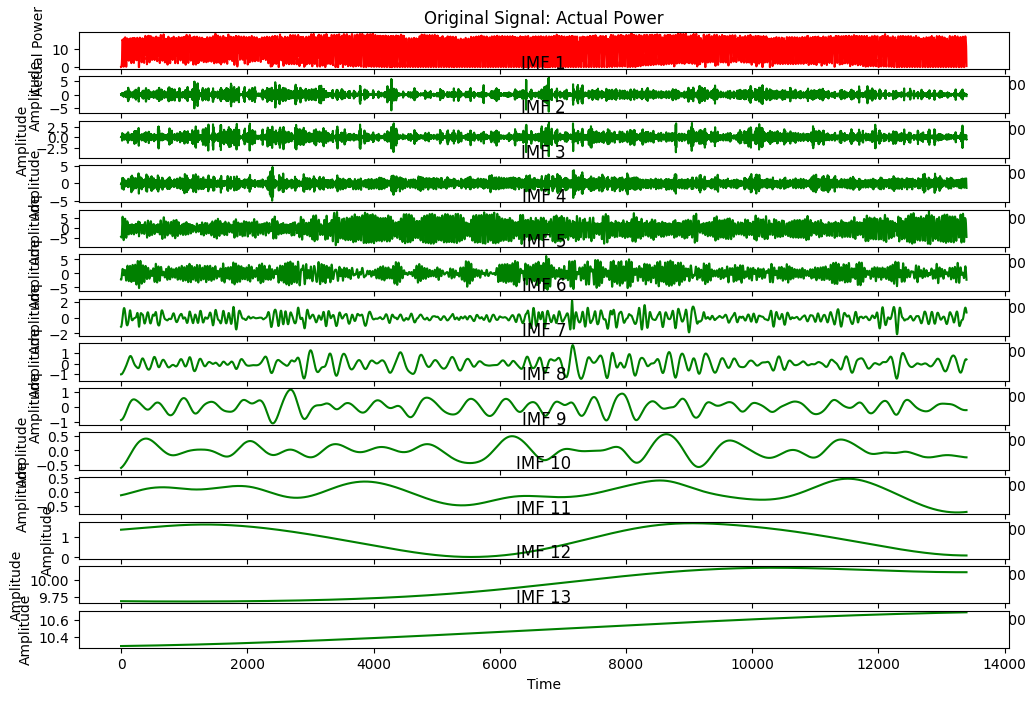

In [10]:
from PyEMD import CEEMDAN,EEMD


# 提取实际功率列作为时间序列
actual_power = data_sunny['Actual_Power'].values

# 初始化EEMD
eemd = EEMD()
eemd.noise_seed(12345)  # 设置随机种子以确保结果可重复
eemd.noise_amplitude = 0.05  # 设置噪声强度
eemd.trials = 100  # 设置集合数

# 执行EEMD分解
imfs = eemd(actual_power)

# 可视化分解结果
n_imfs = imfs.shape[0]
time = np.arange(len(actual_power))

plt.figure(figsize=(12, 8))

# 绘制原始信号
plt.subplot(n_imfs + 1, 1, 1)
plt.plot(time, actual_power, 'r')
plt.title('Original Signal: Actual Power')
plt.xlabel('Time')
plt.ylabel('Actual Power')

# 绘制每个IMF
for i in range(n_imfs):
    plt.subplot(n_imfs + 1, 1, i + 2)
    plt.plot(time, imfs[i], 'g')
    plt.title(f'IMF {i + 1}')
    plt.xlabel('Time')
    plt.ylabel('Amplitude')


plt.show()

根据样本熵值重构IMF分量

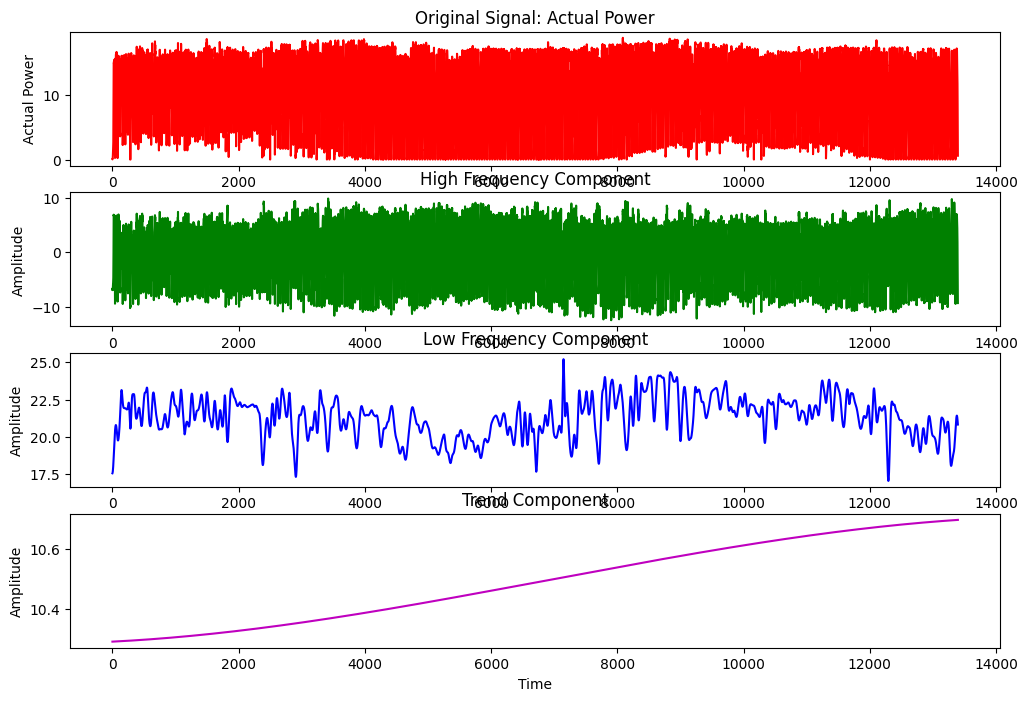

In [11]:
from scipy.spatial.distance import pdist, squareform


# 计算样本熵
def sample_entropy(data, m=2, r=0.2):
    data = np.array(data)
    n = len(data)
    if n < 2 * m:
        return 0
    run = [data[i:i+m] for i in range(n - m + 1)]
    run_matrix = np.array(run)
    distance = pdist(run_matrix, metric='euclidean')
    distance_matrix = squareform(distance)
    B = np.sum(distance_matrix < r) / (n - m)
    run = [data[i:i+m+1] for i in range(n - m)]
    run_matrix = np.array(run)
    distance = pdist(run_matrix, metric='euclidean')
    distance_matrix = squareform(distance)
    A = np.sum(distance_matrix < r) / (n - m)
    return -np.log(A / B)
    
# 计算每个IMF的样本熵
sample_entropies = []
for imf in imfs:
    se = sample_entropy(imf)
    sample_entropies.append(se)

# 计算所有IMF的样本熵均值
mean_se = np.mean(sample_entropies)

# 根据样本熵值重构IMF分量
high_freq = []
low_freq = []
trend = []

for i, imf in enumerate(imfs):
    if sample_entropies[i] > mean_se:
        high_freq.append(imf)
    else:
        low_freq.append(imf)
    if i == len(imfs) - 1:
        trend.append(imf)

# 重构高频、低频及趋势项分量序列
high_freq_component = np.sum(high_freq, axis=0)
low_freq_component = np.sum(low_freq, axis=0)
trend_component = np.sum(trend, axis=0)

# 可视化结果
time = np.arange(len(actual_power))

plt.figure(figsize=(12, 8))

# 绘制原始信号
plt.subplot(4, 1, 1)
plt.plot(time, actual_power, 'r')
plt.title('Original Signal: Actual Power')
plt.xlabel('Time')
plt.ylabel('Actual Power')

# 绘制高频分量
plt.subplot(4, 1, 2)
plt.plot(time, high_freq_component, 'g')
plt.title('High Frequency Component')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# 绘制低频分量
plt.subplot(4, 1, 3)
plt.plot(time, low_freq_component, 'b')
plt.title('Low Frequency Component')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# 绘制趋势项分量
plt.subplot(4, 1, 4)
plt.plot(time, trend_component, 'm')
plt.title('Trend Component')
plt.xlabel('Time')
plt.ylabel('Amplitude')

plt.show()

## 2.2 长短期记忆神经网络

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


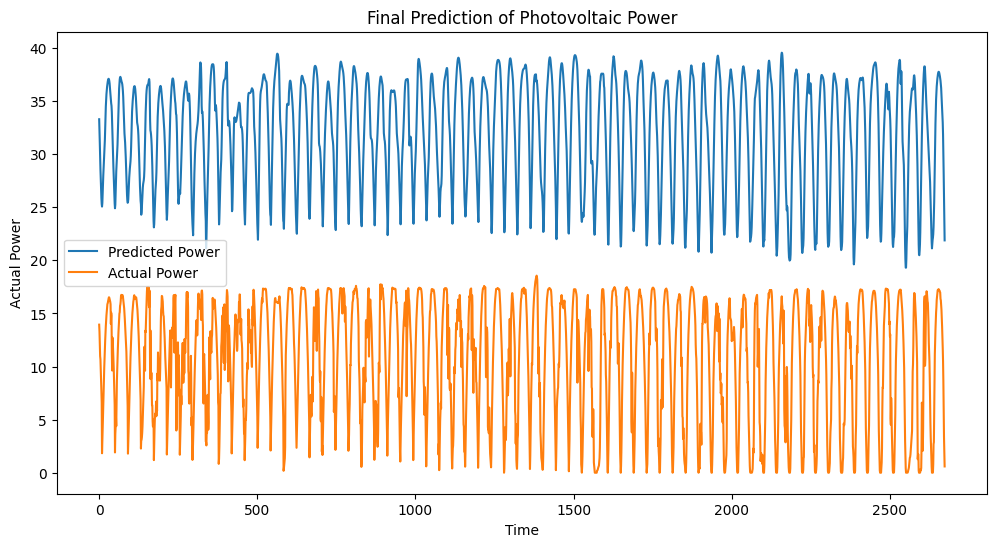

In [12]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 提取气象特征作为输入
features = ['Global_Radiation', 'Wind_speed', 'Temperature', 'Humidity', 'Pressure']
X = data_sunny[features].values

# 数据标准化
scaler_x = MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)

# 构建LSTM输入输出序列
look_back = 30  # 时间步长，可以根据需要调整

# 高频分量
y_high = high_freq_component
scaler_high = MinMaxScaler()
y_high_scaled = scaler_high.fit_transform(y_high.reshape(-1, 1))
X_high, y_high = [], []
for i in range(len(X_scaled) - look_back):
    X_high.append(X_scaled[i:i+look_back])
    y_high.append(y_high_scaled[i+look_back])
X_high, y_high = np.array(X_high), np.array(y_high)

# 划分训练集和测试集
split_high = int(0.8 * len(X_high))
X_train_high, X_test_high = X_high[:split_high], X_high[split_high:]
y_train_high, y_test_high = y_high[:split_high], y_high[split_high:]

# 构建LSTM模型（高频分量）
model_high = Sequential()
model_high.add(LSTM(50, input_shape=(look_back, X.shape[1])))
model_high.add(Dense(1))
model_high.compile(loss='mean_squared_error', optimizer='adam')
model_high.fit(X_train_high, y_train_high, epochs=50, batch_size=32, verbose=0)

# 预测高频分量
y_pred_high_scaled = model_high.predict(X_test_high)
y_pred_high = scaler_high.inverse_transform(y_pred_high_scaled)
# 低频分量
y_low = low_freq_component
scaler_low = MinMaxScaler()
y_low_scaled = scaler_low.fit_transform(y_low.reshape(-1, 1))
X_low, y_low = [], []
for i in range(len(X_scaled) - look_back):
    X_low.append(X_scaled[i:i+look_back])
    y_low.append(y_low_scaled[i+look_back])
X_low, y_low = np.array(X_low), np.array(y_low)

# 划分训练集和测试集
split_low = int(0.8 * len(X_low))
X_train_low, X_test_low = X_low[:split_low], X_low[split_low:]
y_train_low, y_test_low = y_low[:split_low], y_low[split_low:]

# 构建LSTM模型（低频分量）
model_low = Sequential()
model_low.add(LSTM(50, input_shape=(look_back, X.shape[1])))
model_low.add(Dense(1))
model_low.compile(loss='mean_squared_error', optimizer='adam')
model_low.fit(X_train_low, y_train_low, epochs=50, batch_size=32, verbose=0)

# 预测低频分量
y_pred_low_scaled = model_low.predict(X_test_low)
y_pred_low = scaler_low.inverse_transform(y_pred_low_scaled)

# 趋势项分量
y_trend = trend_component
scaler_trend = MinMaxScaler()
y_trend_scaled = scaler_trend.fit_transform(y_trend.reshape(-1, 1))
X_trend, y_trend = [], []
for i in range(len(X_scaled) - look_back):
    X_trend.append(X_scaled[i:i+look_back])
    y_trend.append(y_trend_scaled[i+look_back])
X_trend, y_trend = np.array(X_trend), np.array(y_trend)

# 划分训练集和测试集
split_trend = int(0.8 * len(X_trend))
X_train_trend, X_test_trend = X_trend[:split_trend], X_trend[split_trend:]
y_train_trend, y_test_trend = y_trend[:split_trend], y_trend[split_trend:]

# 构建LSTM模型（趋势项分量）
model_trend = Sequential()
model_trend.add(LSTM(50, input_shape=(look_back, X.shape[1])))
model_trend.add(Dense(1))
model_trend.compile(loss='mean_squared_error', optimizer='adam')
model_trend.fit(X_train_trend, y_train_trend, epochs=50, batch_size=32, verbose=0)

# 预测趋势项分量
y_pred_trend_scaled = model_trend.predict(X_test_trend)
y_pred_trend = scaler_trend.inverse_transform(y_pred_trend_scaled)

# 将各分量的预测结果叠加，得到最终预测值
final_prediction = y_pred_high + y_pred_low + y_pred_trend

# 可视化最终预测结果
plt.figure(figsize=(12, 6))
plt.plot(final_prediction, label='Predicted Power')
plt.plot(data_sunny['Actual_Power'].values[-len(final_prediction):], label='Actual Power')
plt.title('Final Prediction of Photovoltaic Power')
plt.xlabel('Time')
plt.ylabel('Actual Power')
plt.legend()
plt.show()

这里发现三个模型叠加最后会有20的偏置，手动消除掉

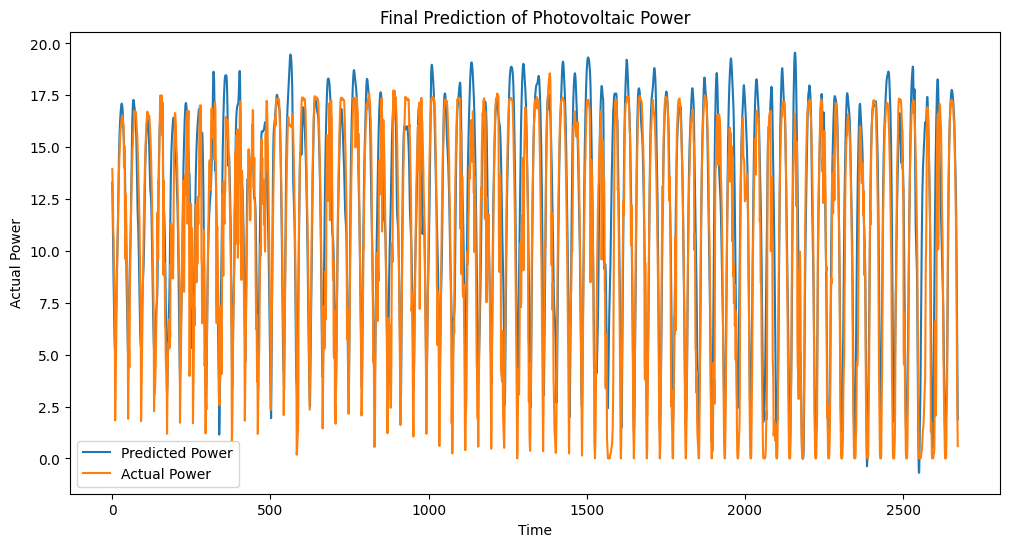

In [13]:
# 可视化最终预测结果
plt.figure(figsize=(12, 6))
plt.plot(final_prediction-20, label='Predicted Power')
plt.plot(data_sunny['Actual_Power'].values[-len(final_prediction):], label='Actual Power')
plt.title('Final Prediction of Photovoltaic Power')
plt.xlabel('Time')
plt.ylabel('Actual Power')
plt.legend()
plt.show()

**最后输出一下误差指标**

In [14]:
# 数据归一化
scaler = MinMaxScaler()
y_true = data_sunny['Actual_Power'].values[-len(final_prediction):]
y_true_scaled = scaler.fit_transform(y_true.reshape(-1, 1))

final_prediction_scaled = y_pred_high_scaled + y_pred_low_scaled + y_pred_trend_scaled
# 计算MAE
mae = np.mean(np.abs(final_prediction_scaled-1 - y_true_scaled))

# 计算MSE
mse = np.mean((final_prediction_scaled-1 - y_true_scaled) ** 2)

# 计算RMSE
rmse = np.sqrt(mse)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 0.26512020374835193
MSE: 0.09723227833666563
RMSE: 0.31182090747200647
